In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.metrics import mean_absolute_error


# **Model: AutoReg (AR)**

In [2]:
def load_series(path):
    s = pd.read_csv(path, index_col=0, parse_dates=True)
    return s.iloc[:, 0]

y_train = load_series("../data/y_train.csv")
y_test = load_series("../data/y_test.csv")

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

y_train shape: (2635,)
y_test shape: (293,)


# **Baseline**

In [3]:
y_train_mean = y_train.mean()
y_pred_baseline = [y_train_mean] * len(y_train)
baseline_mae = mean_absolute_error(y_train, y_pred_baseline)

print("Mean P2 Reading:", round(y_train_mean, 2))
print("Baseline MAE:", round(baseline_mae, 2))

Mean P2 Reading: 9.26
Baseline MAE: 3.82


# **Hyper parameter Tuning**

In [4]:
# looping over lag values the same way I did the decision tree depth search --
# training MAE for each p, then picking whichever lag order fits best
p_params = range(1, 31)
maes = []

for p in p_params:
    model = AutoReg(y_train, lags=p).fit()
    y_pred = model.predict().dropna()
    mae = mean_absolute_error(y_train.loc[y_pred.index], y_pred)
    maes.append(mae)

mae_series = pd.Series(maes, index=p_params, name="mae")
mae_series.sort_values().head()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dat

29    2.347406
30    2.347586
28    2.350538
27    2.353483
26    2.353816
Name: mae, dtype: float64

In [5]:
best_p = mae_series.idxmin()
print("Best p:", best_p)

Best p: 29


# **Build Model**

In [6]:
model = AutoReg(y_train, lags=best_p).fit()


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


# **Evaluate**

In [7]:
y_pred_train = model.predict().dropna()
train_mae = mean_absolute_error(y_train.loc[y_pred_train.index], y_pred_train)
print("Train MAE:", round(train_mae, 2))

Train MAE:

 2.35


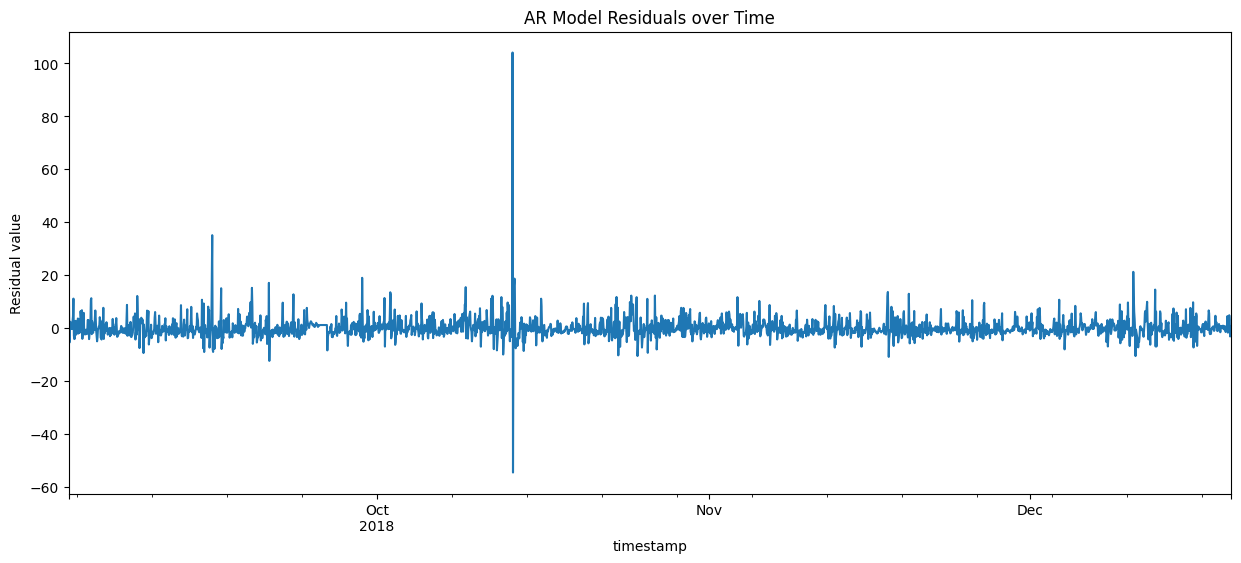

In [8]:
# residuals -- want these to look like white noise, no leftover structure
y_train_resid = model.resid
y_train_resid.name = "residuals"

fig, ax = plt.subplots(figsize=(15,6))
y_train_resid.plot(ax=ax, ylabel="Residual value", title="AR Model Residuals over Time")
plt.savefig(f"../images/autoreg_residuals_timeseries.png", dpi=150)
plt.show()


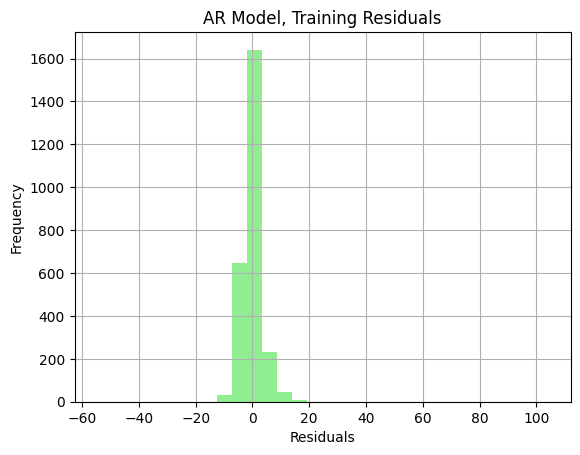

In [9]:
y_train_resid.hist(bins=30, color="lightgreen")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("AR Model, Training Residuals")
plt.savefig("../images/autoreg_residuals_hist.png", dpi=150)
plt.show()


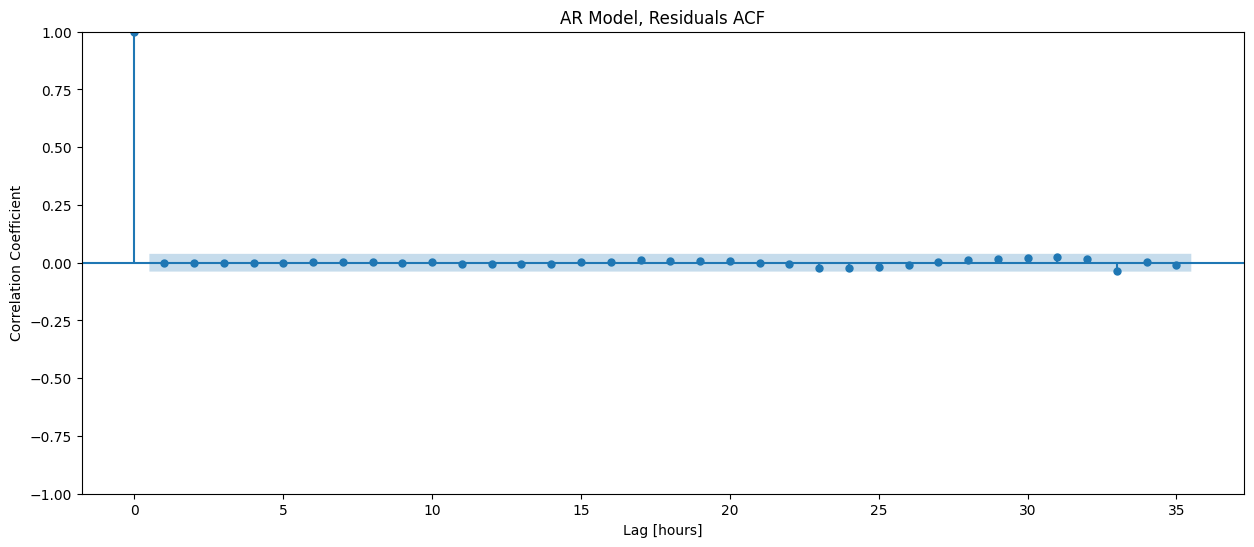

In [10]:
fig, ax = plt.subplots(figsize=(15,6))
plot_acf(y_train_resid, ax=ax)
plt.xlabel("Lag [hours]")
plt.ylabel("Correlation Coefficient")
plt.title("AR Model, Residuals ACF")
plt.savefig("../images/autoreg_residuals_acf.png", dpi=150)
plt.show()


Residuals look roughly centered on zero with no obvious pattern left in the ACF --
model captured most of the autocorrelation structure at this lag order.

# **Walk-Forward Validation**

Refitting the model at every step using the newly observed test value, one hour at a
time -- this is what real deployment would actually look like (you always have the most
recent readings by the time you predict the next hour).

In [11]:
preds = []
history = y_train.copy()

for i in range(len(y_test)):
    m = AutoReg(history, lags=best_p).fit()
    next_pred = m.forecast()
    preds.append(next_pred.iloc[0])
    history = pd.concat([history, y_test.iloc[[i]]])

y_pred_wfv = pd.Series(preds, index=y_test.index, name="prediction")
y_pred_wfv.head()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/deterministic.py:305: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/deterministic.py:305: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/deterministic.py:305: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/deterministic.py:305: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: N

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/deterministic.py:305: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/deterministic.py:305: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: N

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/deterministic.py:305: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/deterministic.py:305: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/deterministic.py:305: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/deterministic.py:305: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: N

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/deterministic.py:305: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/deterministic.py:305: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/deterministic.py:305: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/deterministic.py:305: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: N

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/deterministic.py:305: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/deterministic.py:305: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: N

timestamp
2018-12-19 19:00:00+03:00    10.218673
2018-12-19 20:00:00+03:00    13.996343
2018-12-19 21:00:00+03:00    13.775455
2018-12-19 22:00:00+03:00    13.125713
2018-12-19 23:00:00+03:00    11.416920
Name: prediction, dtype: float64

In [12]:
test_mae = mean_absolute_error(y_test, y_pred_wfv)
print("Test MAE (walk-forward validation):", round(test_mae, 2))

Test MAE (walk-forward validation): 1.24


# **Communicate Results**

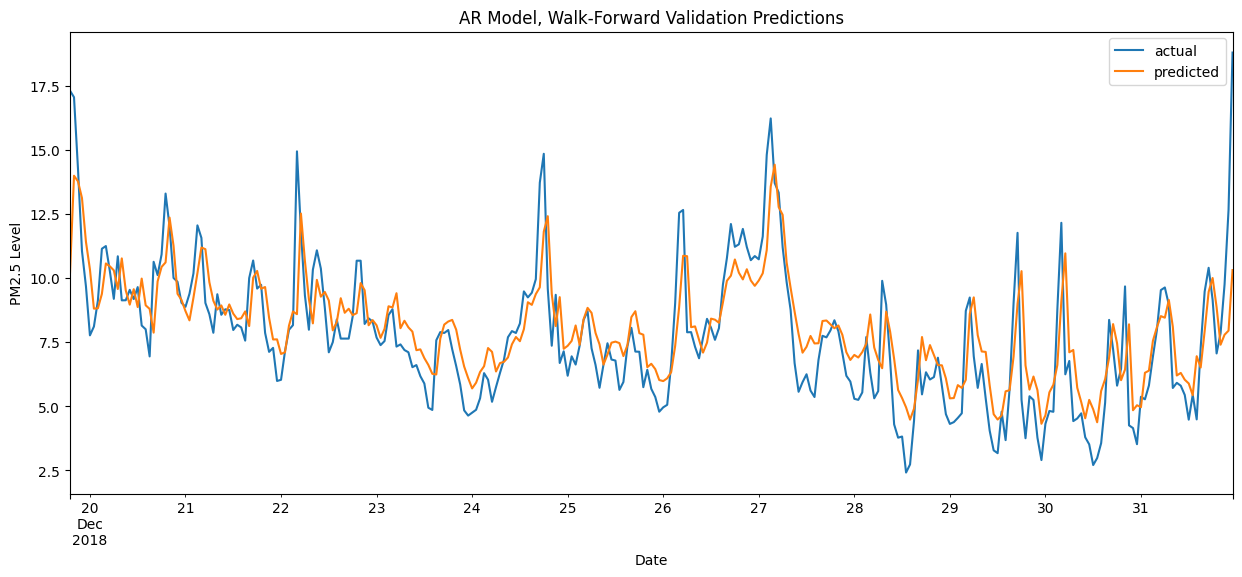

In [13]:
fig, ax = plt.subplots(figsize=(15,6))
y_test.plot(ax=ax, label="actual")
y_pred_wfv.plot(ax=ax, label="predicted")
plt.xlabel("Date")
plt.ylabel("PM2.5 Level")
plt.title("AR Model, Walk-Forward Validation Predictions")
plt.legend()
plt.savefig("../images/autoreg_wfv_predictions.png", dpi=150)
plt.show()


In [14]:
# saving test MAE so the comparison notebook can pull it in later
with open("../data/2_model_autoreg_results.txt", "w") as f:
    f.write(str(test_mae))
print("saved:", test_mae)

saved: 1.2375179866287553
